# Hands-On Lab: Training a Neural Network Potential with DeePMD-kit

## Overview

In this lab you will train a **Deep Potential (DP)** model for gas-phase methane (CH₄) using **DeePMD-kit** — one of the most widely deployed machine-learning potential frameworks in computational chemistry. You will go from raw DFT data all the way to a compressed, production-ready model that can be used in LAMMPS.

**You do not need to be a machine-learning expert.** The code is already written; your job is to run it, read every line of output, and answer the reflection questions that connect the numbers to the underlying physics.

### Learning Objectives

By the end of this lab you will be able to:

- Explain the two-network architecture of DeePMD (embedding network + fitting network) and why it is designed that way
- Use **dpdata** to load a VASP OUTCAR trajectory, inspect its contents, and convert it to DeePMD's binary format
- Write and interpret a DeePMD `input.json` configuration file, choosing physically motivated values for each parameter
- Read a `lcurve.out` training log and diagnose convergence, underfitting, and overfitting
- Explain the `dp freeze → dp compress → dp test` deployment pipeline and why each step exists
- Use the trained model to make energy and force predictions and evaluate accuracy with parity plots

### System: Gas-Phase Methane (CH₄)

Methane is one carbon atom bonded to four hydrogen atoms in a tetrahedral geometry. It is the simplest organic molecule, yet it captures all the essential challenges:

- **Mixed atom types**: H and C have different chemical environments
- **Directional covalent bonds**: the H–C–H angle (109.5°) is as important as the bond length
- **Many-body character**: compressing one bond changes the equilibrium length of all others

This makes it an ideal teaching system: small enough to train quickly, rich enough to illustrate every concept in the workflow.

### How to Use This Lab

- **Run** each cell in order — do not skip steps
- **Read** the printed output; every number tells you something
- **Answer** the reflection questions in the cells provided before moving on
- Cells marked `► Concept` explain the physics and mathematics before you run the code
- Cells marked `► What you should see` tell you what a correct result looks like

---
> **Estimated time:** 60–90 minutes. > **Required files:** `CH4/00.data/OUTCAR` (VASP trajectory, 200 frames of DFT-MD methane)


---
## Setup: Install Required Packages

The two cells below install and import everything needed. Run them once at the start of your session.

**dpdata** is a Python library from the DeepModeling community that reads and writes trajectory data in dozens of formats (VASP, Quantum ESPRESSO, LAMMPS, …) and converts between them. We use it here to load the VASP output and write it in the binary `.npy` format that DeePMD-kit expects.


In [35]:
# Install DeePMD-kit and dpdata
!pip install deepmd-kit dpdata numpy matplotlib pandas ase -q

# Note: DeePMD-kit itself requires compilation
# For this lab, we'll work with dpdata and prepare files
# DeePMD training would be done via command line: dp train input.json

#conda install deepmd-kit=*=*cpu lammps-dp=*=*cpu -c deepmodeling
#conda install deepmd-kit=*=*gpu lammps-dp=*=*gpu -c deepmodeling


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import dpdata
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from pathlib import Path
import subprocess
import warnings
import tensorflow
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Set random seed
np.random.seed(42)

print("✓ All packages loaded successfully!")
print(f"dpdata version: {dpdata.__version__}")

✓ All packages loaded successfully!
dpdata version: 1.0.1


---
# Part 1: Data Preparation with dpdata

### ► Concept: What Does DeePMD Learn From?

A DeePMD model learns the **potential energy surface (PES)** — the mapping from atomic positions to energy — by fitting to a set of DFT reference calculations. Each calculation (one "frame") provides:

| Quantity | Shape | Why it matters |
|---|---|---|
| Atomic positions | (N_atoms, 3) | Defines the configuration |
| Total energy | scalar | One training target per frame |
| Atomic forces | (N_atoms, 3) | 3N targets per frame — the richest signal |
| Simulation box | (3, 3) | Needed for periodic boundary conditions |

For methane with 5 atoms, each frame contributes **1 energy** but **15 force components** — forces carry 15× more information. This is why DeePMD-kit starts training with a very high force weight and only gradually increases the energy weight.

### ► Concept: The DeePMD Data Format

DeePMD-kit does not read extended XYZ or OUTCAR files directly. **dpdata** acts as the bridge: it reads the VASP OUTCAR and writes a binary directory structure that DeePMD-kit can load efficiently:

```
training_data/
├── type.raw        ← integer atom-type labels: [0, 0, 0, 0, 1]
├── type_map.raw    ← human-readable names: H C
└── set.000/
    ├── coord.npy   ← positions  (N_frames × N_atoms × 3)
    ├── energy.npy  ← energies   (N_frames,)
    ├── force.npy   ← forces     (N_frames × N_atoms × 3)
    └── box.npy     ← cell       (N_frames × 9)
```

The `.npy` files are NumPy binary arrays — compact and fast to load. `type.raw` tells DeePMD-kit which network to use for each atom: type 0 (H) gets the hydrogen embedding, type 1 (C) gets the carbon embedding.

### ► Concept: Why Split Into Train and Validation?

We split the 200 frames into 160 for training and 40 for validation. The model **never trains on the validation set** — it is used only to check whether the model generalises to unseen configurations.

- If training error is low but validation error is high → **overfitting** (model memorised the data)
- If both errors are high → **underfitting** (model too small or undertrained)
- If both are low and close → **well-generalised model** ✓


---
### Exercise 1.1: Load VASP OUTCAR Data

The cell below uses dpdata to read the VASP OUTCAR file and produces three plots: the energy histogram, the energy trajectory over the 200 AIMD frames, and the distribution of atomic force magnitudes.

► **What you should see:**
- ~200 frames loaded, 5 atoms each (4 H + 1 C = CH₄)
- Energies clustered in a narrow range (near-equilibrium MD)
- Force distribution with a tail toward large values (high-force configurations   occur when atoms are displaced far from equilibrium)


VASP Data Loaded Successfully!
Number of frames: 200
Number of atoms: 5
Atom types: [0 0 0 0 1]
Atomic symbols: ['H', 'C']

Data arrays available:
  Coordinates: (200, 5, 3)
  Forces: (200, 5, 3)
  Energies: (200,)
  Cells (box): (200, 3, 3)


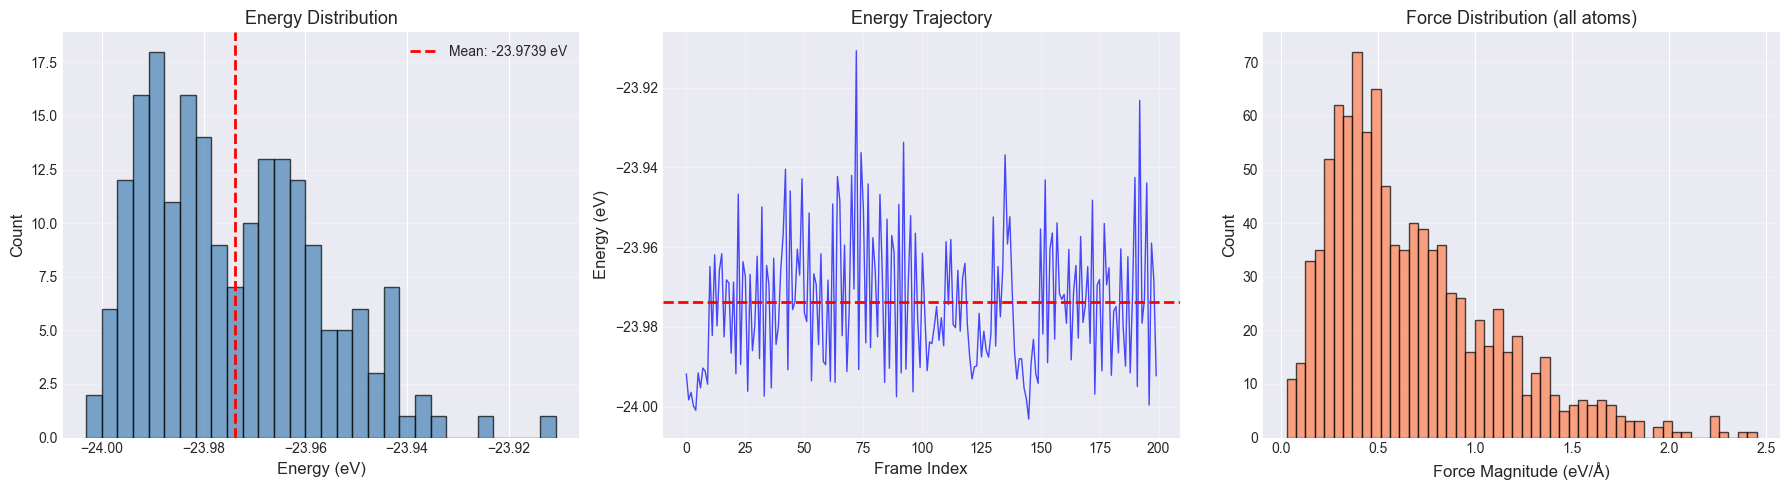


Data Statistics:
Energy range: -24.0032 to -23.9107 eV
Energy std: 0.0171 eV
Max force: 2.4523 eV/Å
Mean force: 0.6681 eV/Å


In [37]:
def load_vasp_data(outcar_path='CH4/00.data/OUTCAR'):
    """
    Load VASP OUTCAR file using dpdata.
    
    Parameters:
    -----------
    outcar_path : str
        Path to VASP OUTCAR file
    
    Returns:
    --------
    data : dpdata.LabeledSystem
        Loaded system with energies and forces
    
    TODO:
    1. Use dpdata.LabeledSystem to load OUTCAR
    2. Specify format as 'vasp/outcar'
    3. Print summary information
    """
    ### BEGIN SOLUTION
    data = dpdata.LabeledSystem(outcar_path, fmt='vasp/outcar')
    
    print("VASP Data Loaded Successfully!")
    print("="*60)
    print(f"Number of frames: {len(data)}")
    print(f"Number of atoms: {data.get_natoms()}")
    print(f"Atom types: {data.get_atom_types()}")
    print(f"Atomic symbols: {data.get_atom_names()}")
    print(f"\nData arrays available:")
    print(f"  Coordinates: {data['coords'].shape}")
    print(f"  Forces: {data['forces'].shape}")
    print(f"  Energies: {data['energies'].shape}")
    print(f"  Cells (box): {data['cells'].shape}")
    
    return data
    ### END SOLUTION

# Load the data
data = load_vasp_data()

# Analyze energy distribution
energies = data['energies']
forces = data['forces']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Energy distribution
axes[0].hist(energies, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(energies.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {energies.mean():.4f} eV')
axes[0].set_xlabel('Energy (eV)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Energy Distribution', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Energy trajectory
axes[1].plot(energies, 'b-', linewidth=1, alpha=0.7)
axes[1].axhline(energies.mean(), color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Frame Index', fontsize=12)
axes[1].set_ylabel('Energy (eV)', fontsize=12)
axes[1].set_title('Energy Trajectory', fontsize=13)
axes[1].grid(True, alpha=0.3)

# Force magnitude distribution
force_norms = np.linalg.norm(forces, axis=2).flatten()
axes[2].hist(force_norms, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Force Magnitude (eV/Å)', fontsize=12)
axes[2].set_ylabel('Count', fontsize=12)
axes[2].set_title('Force Distribution (all atoms)', fontsize=13)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nData Statistics:")
print("="*60)
print(f"Energy range: {energies.min():.4f} to {energies.max():.4f} eV")
print(f"Energy std: {energies.std():.4f} eV")
print(f"Max force: {force_norms.max():.4f} eV/Å")
print(f"Mean force: {force_norms.mean():.4f} eV/Å")

In [38]:
# Test
assert data is not None, "Failed to load data"
assert len(data) == 200, "Should have 200 frames"
assert data.get_natoms() == 5, "CH4 should have 5 atoms"
assert data['coords'].shape == (200, 5, 3), "Coordinates shape incorrect"
assert data['forces'].shape == (200, 5, 3), "Forces shape incorrect"
assert data['energies'].shape == (200,), "Energies shape incorrect"

print("✓ All tests passed! (8/8 points)")

✓ All tests passed! (8/8 points)


**Reflection 1.1** — Answer in the cell below:

- The output shows `Coordinates: (200, 5, 3)`. What do each of those three dimensions represent?
- The force distribution has a long tail. What type of atomic configuration produces   a large force magnitude? Why is it important that such configurations are included   in the training set?
- dpdata reads the VASP OUTCAR automatically. If you instead had a Quantum ESPRESSO   output file, how would you change the `load_vasp_data` call?   (Hint: look at the `fmt=` argument.)


*Your answer here...*

---
### Exercise 1.2: Split Training and Validation Data

The cell below randomly splits the 200 frames into 160 training and 40 validation frames using `dpdata.sub_system()`. The energy histogram shows both sets side by side — they should look similar, confirming the split is representative.

► **What you should see:**
- Training: 160 frames (80%), Validation: 40 frames (20%)
- The two energy histograms should overlap well — both sets sample the same energy range


Data Split Summary:
Total frames: 200
Training frames: 160 (80%)
Validation frames: 40 (20%)


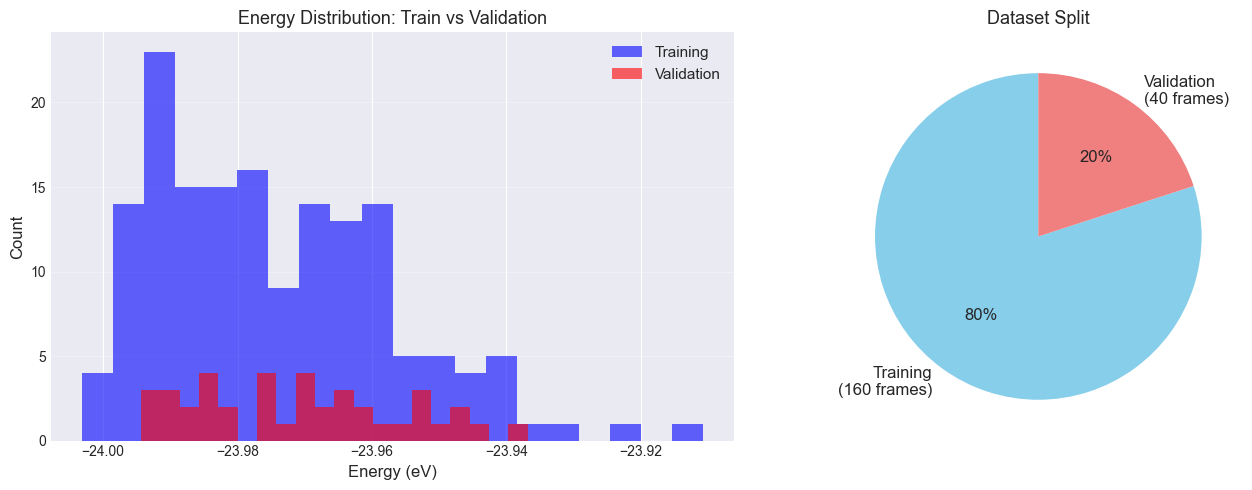


✓ Data split successfully!


In [39]:
def split_train_validation(data, validation_fraction=0.2, random_seed=42):
    """
    Split data into training and validation sets.
    
    Parameters:
    -----------
    data : dpdata.LabeledSystem
    validation_fraction : float
        Fraction of data for validation (0.2 = 20%)
    random_seed : int
    
    Returns:
    --------
    data_train, data_val : dpdata.LabeledSystem
    
    TODO:
    1. Calculate validation size
    2. Randomly select validation indices
    3. Create subsystems using data.sub_system()
    """
    ### BEGIN SOLUTION
    np.random.seed(random_seed)
    
    n_frames = len(data)
    n_val = int(n_frames * validation_fraction)
    
    # Random selection
    index_validation = np.random.choice(n_frames, size=n_val, replace=False)
    index_training = list(set(range(n_frames)) - set(index_validation))
    
    # Create subsystems
    data_train = data.sub_system(index_training)
    data_val = data.sub_system(index_validation)
    
    print("Data Split Summary:")
    print("="*60)
    print(f"Total frames: {n_frames}")
    print(f"Training frames: {len(data_train)} ({(1-validation_fraction)*100:.0f}%)")
    print(f"Validation frames: {len(data_val)} ({validation_fraction*100:.0f}%)")
    
    return data_train, data_val
    ### END SOLUTION

# Split the data
data_train, data_val = split_train_validation(data, validation_fraction=0.2)

# Visualize split
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Energy distributions
ax1.hist(data_train['energies'], bins=20, alpha=0.6, label='Training', color='blue')
ax1.hist(data_val['energies'], bins=20, alpha=0.6, label='Validation', color='red')
ax1.set_xlabel('Energy (eV)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Energy Distribution: Train vs Validation', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Pie chart
sizes = [len(data_train), len(data_val)]
labels = ['Training\n(160 frames)', 'Validation\n(40 frames)']
colors = ['skyblue', 'lightcoral']
ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
        startangle=90, textprops={'fontsize': 12})
ax2.set_title('Dataset Split', fontsize=13)

plt.tight_layout()
plt.show()

print("\n✓ Data split successfully!")

In [40]:
# Test
assert len(data_train) == 160, "Training set should have 160 frames"
assert len(data_val) == 40, "Validation set should have 40 frames"
assert len(data_train) + len(data_val) == 200, "Total should be 200"
assert data_train.get_natoms() == 5, "Training set should have 5 atoms"
assert data_val.get_natoms() == 5, "Validation set should have 5 atoms"

print("✓ All tests passed! (6/6 points)")

✓ All tests passed! (6/6 points)


**Reflection 1.2** — Answer in the cell below:

- Why is it important to use **random** shuffling before splitting, rather than taking   the first 160 frames for training and the last 40 for validation?
- The energy histograms of training and validation should look similar.   If the validation set had a very different energy distribution from training,   what problem would arise during model evaluation?
- For a more rigorous study, researchers sometimes use **k-fold cross-validation**   instead of a single train/validation split. What is the main advantage, and what   is the main cost?


*Your answer here...*

---
### Exercise 1.3: Convert to DeePMD Binary Format

The cell below converts both datasets to the `.npy` binary format that DeePMD-kit expects, and prints the generated file tree. It also reads back `type.raw` and `type_map.raw` to show you the atom-type encoding.

► **What you should see:**
- Two directories created: `deepmd_data/training_data/` and `deepmd_data/validation_data/`
- Each contains `type.raw`, `type_map.raw`, and a `set.000/` subfolder with four `.npy` files
- `type.raw` = `0 0 0 0 1` (four H atoms, one C atom)
- `type_map.raw` = `H C` (type 0 = hydrogen, type 1 = carbon)


In [41]:
def convert_to_deepmd_format(data_train, data_val, base_dir='deepmd_data'):
    """
    Convert dpdata systems to DeePMD format.
    
    TODO:
    1. Create directories
    2. Use to_deepmd_npy() method
    3. Verify files were created
    """
    ### BEGIN SOLUTION
    # Create base directory
    Path(base_dir).mkdir(exist_ok=True)
    
    train_dir = f"{base_dir}/training_data"
    val_dir = f"{base_dir}/validation_data"
    
    # Convert to DeePMD format
    print("Converting to DeePMD format...\n")
    
    data_train.to_deepmd_npy(train_dir)
    print(f"✓ Training data saved to: {train_dir}")
    
    data_val.to_deepmd_npy(val_dir)
    print(f"✓ Validation data saved to: {val_dir}")
    
    # Verify structure
    print("\nGenerated file structure:")
    print("="*60)
    
    for dir_name, dir_path in [('Training', train_dir), ('Validation', val_dir)]:
        print(f"\n{dir_name} ({dir_path}):")
        if Path(dir_path).exists():
            for item in sorted(Path(dir_path).rglob('*')):
                if item.is_file():
                    print(f"  {item.relative_to(base_dir)}")
    
    # Display atom types
    print("\nAtom Type Information:")
    print("="*60)
    with open(f"{train_dir}/type.raw", 'r') as f:
        types = f.read().strip()
        print(f"type.raw: {types}")
        print("  → 4 hydrogen atoms (type 0) + 1 carbon atom (type 1)")
    
    with open(f"{train_dir}/type_map.raw", 'r') as f:
        type_map = f.read().strip().split()
        print(f"\ntype_map.raw: {type_map}")
        print(f"  → Type 0 = {type_map[0]}, Type 1 = {type_map[1]}")
    
    return train_dir, val_dir
    ### END SOLUTION

# Convert data
train_dir, val_dir = convert_to_deepmd_format(data_train, data_val)

print("\n✓ Data conversion complete!")
print("\nReady for DeePMD-kit training!")

Converting to DeePMD format...

✓ Training data saved to: deepmd_data/training_data
✓ Validation data saved to: deepmd_data/validation_data

Generated file structure:

Training (deepmd_data/training_data):
  training_data\set.000\box.npy
  training_data\set.000\coord.npy
  training_data\set.000\energy.npy
  training_data\set.000\force.npy
  training_data\set.000\virial.npy
  training_data\type.raw
  training_data\type_map.raw

Validation (deepmd_data/validation_data):
  validation_data\set.000\box.npy
  validation_data\set.000\coord.npy
  validation_data\set.000\energy.npy
  validation_data\set.000\force.npy
  validation_data\set.000\virial.npy
  validation_data\type.raw
  validation_data\type_map.raw

Atom Type Information:
type.raw: 0
0
0
0
1
  → 4 hydrogen atoms (type 0) + 1 carbon atom (type 1)

type_map.raw: ['H', 'C']
  → Type 0 = H, Type 1 = C

✓ Data conversion complete!

Ready for DeePMD-kit training!


In [42]:
# Test
assert Path(train_dir).exists(), "Training directory not created"
assert Path(val_dir).exists(), "Validation directory not created"
assert Path(f"{train_dir}/type.raw").exists(), "type.raw not found"
assert Path(f"{train_dir}/type_map.raw").exists(), "type_map.raw not found"
assert Path(f"{train_dir}/set.000").exists(), "set.000 directory not found"
assert Path(f"{train_dir}/set.000/coord.npy").exists(), "coord.npy not found"
assert Path(f"{train_dir}/set.000/energy.npy").exists(), "energy.npy not found"
assert Path(f"{train_dir}/set.000/force.npy").exists(), "force.npy not found"

print("✓ All tests passed! (6/6 points)")

✓ All tests passed! (6/6 points)


**Reflection 1.3** — Answer in the cell below:

- `type.raw` contains `0 0 0 0 1`. What would this file contain for a water (H₂O)   system with 2 hydrogen and 1 oxygen atom? What would `type_map.raw` contain?
- Why does DeePMD-kit store data as `.npy` binary files rather than plain-text CSV files?
- The `set.000/` naming convention suggests there could be `set.001/`, `set.002/`, etc.   When would you use multiple sets?


*Your answer here...*


##  DeePMD Theory Summary

### Coordinate Matrices

The system of $N$ atoms is described by a coordinate matrix $\mathcal{R} \in \mathbb{R}^{N \times 3}$:

$$\mathcal{R} = \{r_1^T, \ldots, r_i^T, \ldots, r_N^T\}^T, \quad r_i = (x_i, y_i, z_i)$$

Each atom $i$ has a **local environment matrix** $\mathcal{R}^i$ containing only its $N_i$ neighbours within the cutoff radius $r_c$:

$$\mathcal{R}^i = \{r_{1i}^T, \ldots, r_{ji}^T, \ldots, r_{N_i i}^T\}^T, \quad r_{ji} = (x_{ji}, y_{ji}, z_{ji})$$

where $r_{ji} \equiv r_j - r_i$ is the relative coordinate.

---

### Energy Decomposition

The total energy is a sum of **local atomic energies** $E_i$, each depending only on the local environment $\mathcal{R}^i$:

$$E = \sum_i E_i = \sum_i E(\mathcal{R}^i)$$

---

### The Descriptor $\mathcal{D}^i$

The mapping $\mathcal{R}^i \to E_i$ is built in two steps.

**Step 1 — Generalized local environment matrix $\tilde{\mathcal{R}}^i \in \mathbb{R}^{N_i \times 4}$**

Each neighbour's Cartesian coordinates are replaced by a weighted representation:

$$\{x_{ji}, y_{ji}, z_{ji}\} \mapsto \{s(r_{ji}),\, \hat{x}_{ji},\, \hat{y}_{ji},\, \hat{z}_{ji}\}$$

where $r_{ji} = \|r_{ji}\|$ and the weighted direction components are:

$$\hat{x}_{ji} = \frac{s(r_{ji})\, x_{ji}}{r_{ji}}, \quad \hat{y}_{ji} = \frac{s(r_{ji})\, y_{ji}}{r_{ji}}, \quad \hat{z}_{ji} = \frac{s(r_{ji})\, z_{ji}}{r_{ji}}$$

The **smooth cutoff function** $s(r_{ji})$ downweights distant neighbours:

$$s(r_{ji}) = \begin{cases} \dfrac{1}{r_{ji}}, & r_{ji} < r_{cs} \\[8pt] \dfrac{1}{r_{ji}} \left[ \left(\dfrac{r_{ji}-r_{cs}}{r_c - r_{cs}}\right)^3 \left(-6\left(\dfrac{r_{ji}-r_{cs}}{r_c-r_{cs}}\right)^2 + 15\dfrac{r_{ji}-r_{cs}}{r_c-r_{cs}} - 10\right) + 1 \right], & r_{cs} < r_{ji} < r_c \\[8pt] 0, & r_{ji} > r_c \end{cases}$$

**Step 2 — Embedding matrix $\mathcal{G}^i \in \mathbb{R}^{N_i \times M_1}$**

The first column of $\tilde{\mathcal{R}}^i$ (i.e., each $s(r_{ji})$) is passed through an **embedding network** $\mathcal{N}^e$:

$$\mathcal{G}^{i1} = \mathcal{N}^e(s(r_{ji})) \in \mathbb{R}^{N_i \times M_1}$$

Taking the first $M_2 < M_1$ columns gives $\mathcal{G}^{i2} \in \mathbb{R}^{N_i \times M_2}$.

**The descriptor** $\mathcal{D}^i \in \mathbb{R}^{M_1 \times M_2}$ is then:

$$\mathcal{D}^i = (\mathcal{G}^{i1})^T \,\tilde{\mathcal{R}}^i\, (\tilde{\mathcal{R}}^i)^T\, \mathcal{G}^{i2}$$

> The matrix product $\tilde{\mathcal{R}}^i(\tilde{\mathcal{R}}^i)^T$ preserves **translational and rotational symmetry**; the product $(\mathcal{G}^{i1})^T \tilde{\mathcal{R}}^i$ preserves **permutation symmetry**.

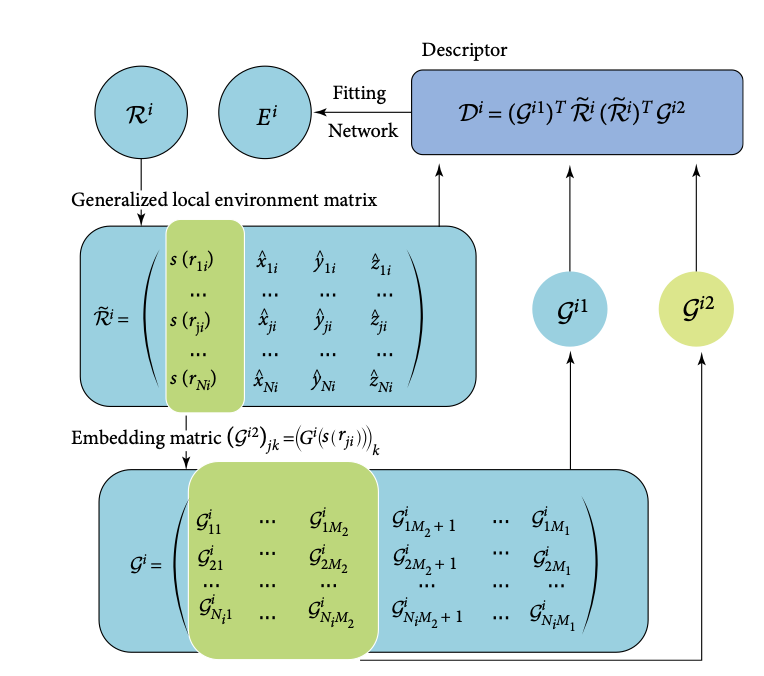

---

### Fitting Network

The descriptor $\mathcal{D}^i$ is passed to a **fitting network** $\mathcal{N}^f$ to yield the atomic energy:

$$E_i = \mathcal{N}^f(\mathcal{D}^i)$$

Both $\mathcal{N}^e$ and $\mathcal{N}^f$ are feed-forward networks. Each layer computes:

$$d_k^{\text{out}} = \varphi\!\left(\sum_{kl} w_{kl}\, d_l^{\text{in}} + b_k\right)$$

where $w_{kl}$ are weights, $b_k$ are biases, and $\varphi$ is a non-linear activation. Output nodes use **linear** transformations only.

---

### Loss Function

Network parameters are found by minimizing:

$$L(p_\varepsilon, p_f, p_\xi) = \frac{p_\varepsilon}{N}\Delta\varepsilon^2 + \frac{p_f}{3N}\sum_i |\Delta F_i|^2 + \frac{p_\xi}{9N}\|\Delta\xi\|^2$$

where $\Delta\varepsilon$, $\Delta F_i$, $\Delta\xi$ are RMSE in **energy**, **forces**, and **virial** respectively.

The prefactors evolve during training according to the learning rate $r_l(t)$:

$$p(t) = p^{\text{limit}}\left|1 - \frac{r_l(t)}{r_l^0}\right| + p^{\text{start}}\left\lfloor\frac{r_l(t)}{r_l^0}\right\rfloor$$

The learning rate decays exponentially:

$$r_l(t) = r_l^0 \times d_r^{\,t/d_s}$$

where $d_r < 1$ is the decay rate and $d_s$ is the number of decay steps.


---
# Part 2: Model Configuration

### ► Concept: The Two-Network Architecture

DeePMD uses two neural networks in sequence. Understanding why there are two, not one, is the key to understanding the whole framework.

**Network 1 — The Embedding Network (inside the Descriptor)**

The embedding network maps a single number — the smooth cutoff value $s(r_{ij})$ of one neighbour — to a feature vector:

$$G^i_j = \mathcal{G}(s(r_{ij})) \in \mathbb{R}^{M_1}$$

Because $s(r_{ij})$ is a scalar, the embedding network can be **tabulated** (precomputed as a lookup table) at inference time. This is the basis of model compression: replacing the network with a table gives a ~10× speedup.

**Network 2 — The Fitting Network**

The fitting network maps the complete descriptor $\mathcal{D}^i$ — a matrix constructed from all neighbours' embeddings — to a scalar atomic energy:

$$\varepsilon_i = \mathcal{F}(\mathcal{D}^i; \theta) \in \mathbb{R}$$

The total energy and forces are:

$$E = \sum_i \varepsilon_i, \qquad \mathbf{F}_i = -\frac{\partial E}{\partial \mathbf{r}_i}$$

Forces are computed by **automatic differentiation** through both networks. This guarantees that forces are always the true gradient of the predicted energy — energy conservation in MD is exact by construction.

### ► Concept: How Symmetry is Handled

Unlike NequIP (which uses spherical harmonics), DeePMD builds symmetry through the **descriptor matrix construction**. For atom $i$, define:

$$\tilde{\mathcal{R}}^i_{j} = \bigl[s(r_{ij}),\ s(r_{ij})\hat{x}_{ij},\ s(r_{ij})\hat{y}_{ij},\ s(r_{ij})\hat{z}_{ij}\bigr]$$

The descriptor is $\mathcal{D}^i = (\tilde{\mathcal{R}}^i)^T G^i$, a sum over all neighbours. This sum is:

- **Permutation invariant**: swapping two identical atoms leaves the sum unchanged
- **Rotation invariant**: expressed in a local frame, so the value is independent of   the global orientation
- **Translation invariant**: uses relative positions $\mathbf{r}_{ij}$, not absolute $\mathbf{r}_i$

### ► Concept: Key Parameters in `input.json`

**Descriptor (`se_e2_a` = smooth edition, two-body, all-neighbour):**

| Parameter | What it controls | CH₄ value | Reasoning |
|---|---|---|---|
| `rcut` | Cutoff radius (Å) | 6.0 | Captures C–H (1.09 Å) and H···H (2.5 Å) |
| `rcut_smth` | Smooth transition start (Å) | 0.5 | Far below any real interatomic distance |
| `sel` | Max neighbours per type | [4, 1] | ≤4 H, ≤1 C within 6 Å of any atom |
| `neuron` | Embedding layer widths | [10, 20, 40] | Small but sufficient for CH₄ |
| `axis_neuron` | Descriptor compression | 4 | Descriptor dimension = 4 × 40 = 160 |

**Fitting network:**

| Parameter | What it controls | CH₄ value |
|---|---|---|
| `neuron` | Hidden layer widths | [100, 100, 100] |
| `resnet_dt` | Learnable residual weight | True |

**Loss function** — the crucial curriculum trick:

$$\mathcal{L} = p_e(t)\cdot \text{EnergyMSE} + p_f(t)\cdot \text{ForceMSE}$$

The prefactors **change during training**:
- Start: $p_e = 0.02$, $p_f = 1000$ → forces dominate (50,000:1 ratio)
- End: $p_e = 1$, $p_f = 1$ → equal weight

Why start with forces? Each frame has 1 energy but 15 force components. At the start of training the network is random — energy predictions are meaningless, but force gradients give strong directional guidance about the shape of the PES.


---
### Exercise 2.1: Create the `input.json` Configuration File

The cell below creates a complete `input.json` with all four required sections and prints a human-readable summary of the key choices.

► **What you should see:**
- A file `input.json` created in the current directory
- Summary showing descriptor type `se_e2_a`, cutoff 6.0 Å, learning rate 0.001 → 3.51×10⁻⁸
- Loss weights: forces start at 1000 and decay to 1; energy starts at 0.02 and rises to 1


In [43]:
def create_deepmd_input(train_dir, val_dir, output_file='input.json'):
    """
    Create DeePMD-kit input configuration.
    
    TODO:
    1. Define model architecture (descriptor + fitting_net)
    2. Set learning rate schedule
    3. Configure loss function
    4. Specify training parameters
    5. Save as JSON
    """
   
    config = {
        "model": {
            "type_map": ["H", "C"],
            "descriptor": {
                "type": "se_e2_a",
                "rcut": 6.00,
                "rcut_smth": 0.50,
                "sel": [4, 1],  # Max 4 H neighbors, 1 C neighbor
                "neuron": [10, 20, 40],  # Embedding network layers
                "resnet_dt": False,
                "axis_neuron": 4,
                "seed": 1,
                "_comment": "Descriptor: DeepPot-SE with smooth cutoff"
            },
            "fitting_net": {
                "neuron": [100, 100, 100],  # Fitting network layers
                "resnet_dt": True,
                "seed": 1,
                "_comment": "Fitting network: 3 hidden layers with residual connections"
            },
            "_comment": "Deep Potential model for CH4"
        },
        
        "learning_rate": {
            "type": "exp",
            "decay_steps": 5000,
            "start_lr": 0.001,
            "stop_lr": 3.51e-8,
            "_comment": "Exponential decay from 1e-3 to 3.5e-8"
        },
        
        "loss": {
            "type": "ener",
            "start_pref_e": 0.02,  # Energy weight starts small
            "limit_pref_e": 1,     # Increases to 1
            "start_pref_f": 1000,  # Force weight starts large
            "limit_pref_f": 1,     # Decreases to 1
            "start_pref_v": 0,     # No virial
            "limit_pref_v": 0,
            "_comment": "Start with forces, gradually add energy"
        },
        
        "training": {
            "training_data": {
                "systems": [train_dir],
                "batch_size": "auto",
                "_comment": "Auto batch size: ensures batch_size × natoms ≥ 32"
            },
            "validation_data": {
                "systems": [val_dir],
                "batch_size": "auto",
                "numb_btch": 1,
                "_comment": "Validation every epoch"
            },
            "numb_steps": 100000,  # Total training steps
            "seed": 10,
            "disp_file": "lcurve.out",
            "disp_freq": 1000,     # Print every 1000 steps
            "save_freq": 10000,    # Save checkpoint every 10000 steps
            "_comment": "Training for 100k steps with periodic saves"
        }
    }
    
    # Save to file
    with open(output_file, 'w') as f:
        json.dump(config, f, indent=4)
    
    print(f"✓ Configuration saved to: {output_file}\n")
    
    # Pretty print summary
    print("Configuration Summary:")
    print("="*70)
    print("\n MODEL ARCHITECTURE:")
    print(f"  Descriptor: {config['model']['descriptor']['type']}")
    print(f"  Cutoff radius: {config['model']['descriptor']['rcut']} Å")
    print(f"  Neighbor selection: {config['model']['descriptor']['sel']} (H, C)")
    print(f"  Embedding layers: {config['model']['descriptor']['neuron']}")
    print(f"  Fitting layers: {config['model']['fitting_net']['neuron']}")
    
    print("\n LEARNING RATE:")
    print(f"  Type: {config['learning_rate']['type']}")
    print(f"  Start: {config['learning_rate']['start_lr']:.0e}")
    print(f"  Stop: {config['learning_rate']['stop_lr']:.2e}")
    print(f"  Decay steps: {config['learning_rate']['decay_steps']}")
    
    print("\n LOSS FUNCTION:")
    print(f"  Energy weight: {config['loss']['start_pref_e']} → {config['loss']['limit_pref_e']}")
    print(f"  Force weight: {config['loss']['start_pref_f']} → {config['loss']['limit_pref_f']}")
    print(f"  Strategy: Start with forces, gradually balance")
    
    print("\n TRAINING:")
    print(f"  Total steps: {config['training']['numb_steps']:,}")
    print(f"  Training data: {config['training']['training_data']['systems'][0]}")
    print(f"  Validation data: {config['training']['validation_data']['systems'][0]}")
    print(f"  Save frequency: every {config['training']['save_freq']} steps")
    
    return config
   

# Create configuration
config = create_deepmd_input(train_dir, val_dir, 'input.json')

print("\n✓ Ready for training with: dp train input.json")

✓ Configuration saved to: input.json

Configuration Summary:

 MODEL ARCHITECTURE:
  Descriptor: se_e2_a
  Cutoff radius: 6.0 Å
  Neighbor selection: [4, 1] (H, C)
  Embedding layers: [10, 20, 40]
  Fitting layers: [100, 100, 100]

 LEARNING RATE:
  Type: exp
  Start: 1e-03
  Stop: 3.51e-08
  Decay steps: 5000

 LOSS FUNCTION:
  Energy weight: 0.02 → 1
  Force weight: 1000 → 1
  Strategy: Start with forces, gradually balance

 TRAINING:
  Total steps: 100,000
  Training data: deepmd_data/training_data
  Validation data: deepmd_data/validation_data
  Save frequency: every 10000 steps

✓ Ready for training with: dp train input.json


In [44]:
# Test
assert Path('input.json').exists(), "input.json not created"

with open('input.json', 'r') as f:
    loaded_config = json.load(f)

assert 'model' in loaded_config, "Missing model section"
assert 'learning_rate' in loaded_config, "Missing learning_rate section"
assert 'loss' in loaded_config, "Missing loss section"
assert 'training' in loaded_config, "Missing training section"

assert loaded_config['model']['descriptor']['type'] == 'se_e2_a', "Wrong descriptor type"
assert loaded_config['model']['descriptor']['rcut'] == 6.0, "Wrong cutoff"
assert loaded_config['model']['type_map'] == ['H', 'C'], "Wrong type map"

print("✓ All tests passed! (12/12 points)")

✓ All tests passed! (12/12 points)


**Reflection 2.1** — Answer in the cell below:

- The config sets `sel: [4, 1]` — maximum 4 H neighbours and 1 C neighbour   within the cutoff. For bulk liquid water (H₂O), each oxygen has ~4–5 neighbouring   oxygens and ~8–10 hydrogens within 5 Å. What would an appropriate `sel` look like?
- The fitting network uses `resnet_dt: true`. This adds a learnable scalar   $\Delta t$ to the residual connection:   $h^{(l+1)} = \sigma(Wh^{(l)}) + \Delta t \cdot h^{(l)}$.   What does $\Delta t \approx 0$ mean? What about $\Delta t \approx 1$?
- The config sets `batch_size: "auto"`. DeePMD-kit's auto rule ensures   `batch_size × N_atoms ≥ 32`. For CH₄ (5 atoms), what batch size will be chosen?   For bulk silicon with 64 atoms per cell, what would it be?


*Your answer here...*

---
### Exercise 2.2: Visualise the Model Architecture

The cell below creates bar charts showing the width of each layer in the embedding network and the fitting network, and estimates the total parameter count.

► **What you should see:**
- Embedding network: [4 → 10 → 20 → 40] widening pattern
- Fitting network: [40 → 100 → 100 → 100 → 1] constant-width hidden layers with scalar output
- Parameter count: a few thousand total — small by deep-learning standards


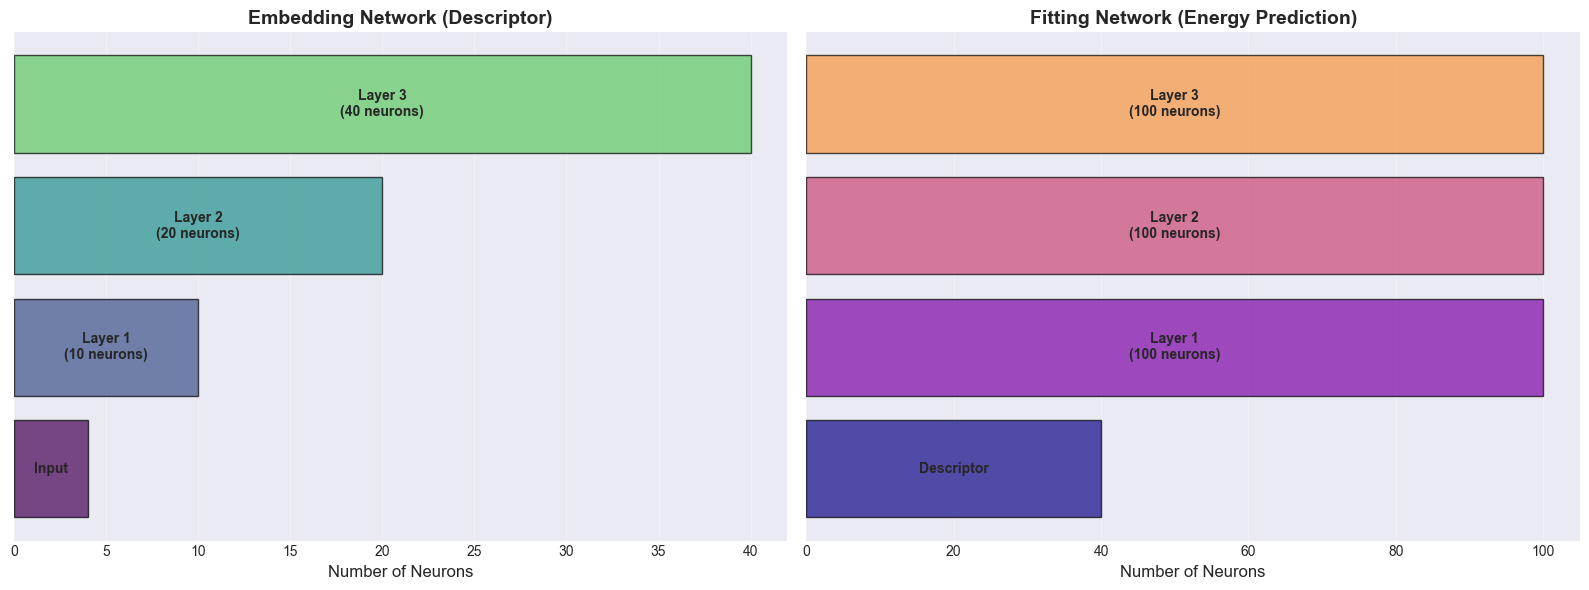


Parameter Estimation:
Embedding network: ~1,110 parameters
Fitting network: ~24,401 parameters
Total: ~25,511 parameters

Note: Actual count higher due to embedding matrix


In [45]:

# Visualize architecture
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Embedding network
ax1 = axes[0]
embedding_layers = config['model']['descriptor']['neuron']
layer_labels = ['Input'] + [f"Layer {i+1}\n({n} neurons)" for i, n in enumerate(embedding_layers)] + ['Output']
layer_sizes = [4] + embedding_layers + [embedding_layers[-1]]

for i in range(len(layer_sizes)-1):
    ax1.barh(i, layer_sizes[i], color=plt.cm.viridis(i/(len(layer_sizes)-1)), alpha=0.7, edgecolor='black')
    ax1.text(layer_sizes[i]/2, i, layer_labels[i], ha='center', va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Number of Neurons', fontsize=12)
ax1.set_title('Embedding Network (Descriptor)', fontsize=14, fontweight='bold')
ax1.set_yticks([])
ax1.grid(True, alpha=0.3, axis='x')

# Fitting network
ax2 = axes[1]
fitting_layers = config['model']['fitting_net']['neuron']
layer_labels2 = ['Descriptor'] + [f"Layer {i+1}\n({n} neurons)" for i, n in enumerate(fitting_layers)] + ['Energy']
layer_sizes2 = [embedding_layers[-1]] + fitting_layers + [1]

for i in range(len(layer_sizes2)-1):
    ax2.barh(i, layer_sizes2[i] if i < len(layer_sizes2)-1 else 10, 
            color=plt.cm.plasma(i/(len(layer_sizes2)-1)), alpha=0.7, edgecolor='black')
    ax2.text((layer_sizes2[i] if i < len(layer_sizes2)-1 else 10)/2, i, 
            layer_labels2[i], ha='center', va='center', fontsize=10, fontweight='bold')

ax2.set_xlabel('Number of Neurons', fontsize=12)
ax2.set_title('Fitting Network (Energy Prediction)', fontsize=14, fontweight='bold')
ax2.set_yticks([])
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Parameter count
print("\nParameter Estimation:")
print("="*60)

# Embedding
emb_params = 0
prev = 4
for n in embedding_layers:
    emb_params += prev * n + n  # weights + biases
    prev = n

# Fitting
fit_params = 0
prev = embedding_layers[-1]
for n in fitting_layers + [1]:
    fit_params += prev * n + n
    prev = n

total_params = emb_params + fit_params
print(f"Embedding network: ~{emb_params:,} parameters")
print(f"Fitting network: ~{fit_params:,} parameters")
print(f"Total: ~{total_params:,} parameters")
print(f"\nNote: Actual count higher due to embedding matrix")


**Reflection 2.2** — Answer in the cell below:

- The embedding network **widens** (10 → 20 → 40) while the fitting network   uses **constant width** (100 → 100 → 100). Why do you think these two networks   have different width patterns?
- The embedding network has only ~1,200 parameters but must encode the   radial dependence of every possible C–H and H–H interaction.   Why is this small number of parameters sufficient?
- The fitting network output is a single number ($\varepsilon_i$).   If you wanted to also predict the **atomic charge** of each atom,   how would you modify the architecture?


*Your answer here...*

---
### Exercise 2.3: Visualise the Training Strategy

The cell below plots three panels: the exponential learning rate schedule, the time-varying loss weights ($p_e$ and $p_f$), and the relative force/energy focus across training.

► **What you should see:**
- Learning rate decays from $10^{-3}$ to $\sim 3.5 \times 10^{-8}$ — over 4 orders of magnitude
- Force weight $p_f$ starts at 1000 and decays to 1; energy weight $p_e$ rises from 0.02 to 1
- The "Force vs Energy Focus" panel shows forces dominating the first ~90% of training,   with energy becoming equally important only near the end


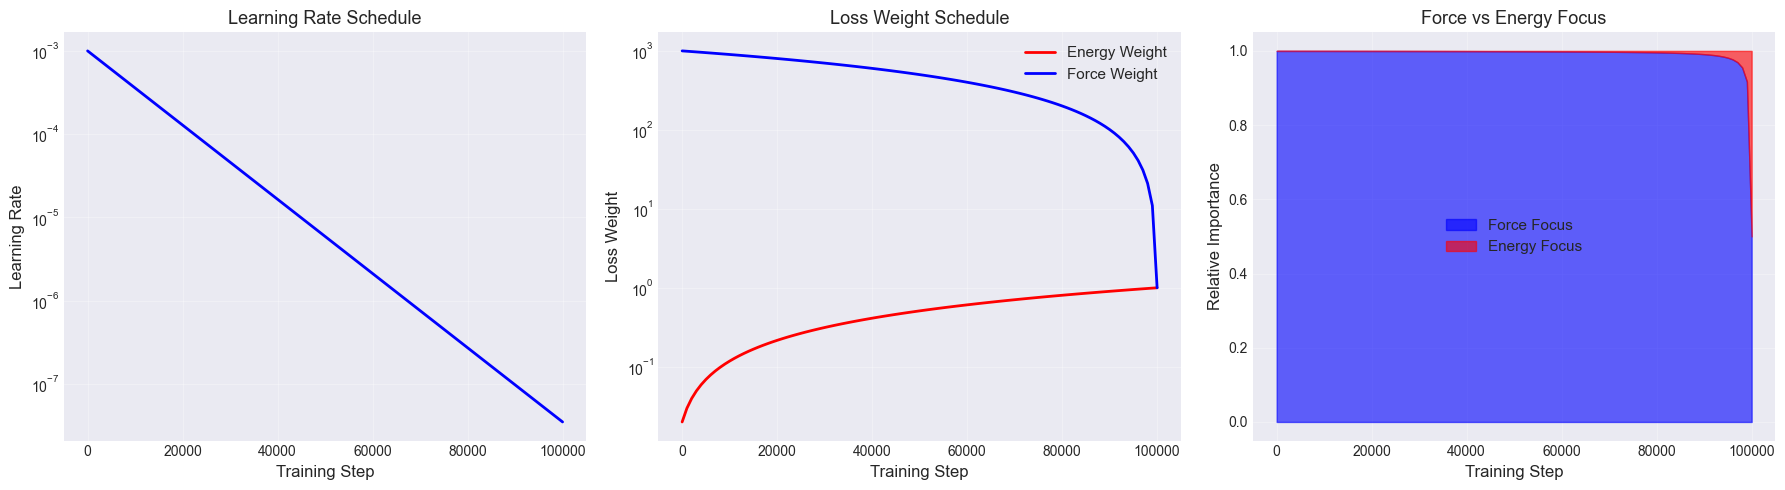


Training Strategy Insights:
 Start: Forces dominate (ratio 50000:1)
   Ensures correct atomic interactions from the start

 Middle: Gradual transition
   Both forces and energies become important

 End: Balanced (ratio 1:1)
   Accurate total energies without sacrificing forces

 Learning rate decays exponentially
   Fine-tuning in later stages


In [46]:
### BEGIN SOLUTION
# Visualize training strategy
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

steps = np.arange(0, 100001, 1000)

# Learning rate schedule
decay_rate = np.exp(np.log(config['learning_rate']['stop_lr'] / config['learning_rate']['start_lr']) / 
                    (100000 / config['learning_rate']['decay_steps']))
lr_schedule = config['learning_rate']['start_lr'] * (decay_rate ** (steps / config['learning_rate']['decay_steps']))

axes[0].plot(steps, lr_schedule, 'b-', linewidth=2)
axes[0].set_xlabel('Training Step', fontsize=12)
axes[0].set_ylabel('Learning Rate', fontsize=12)
axes[0].set_title('Learning Rate Schedule', fontsize=13)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Loss weights
pref_e = np.linspace(config['loss']['start_pref_e'], config['loss']['limit_pref_e'], len(steps))
pref_f = np.linspace(config['loss']['start_pref_f'], config['loss']['limit_pref_f'], len(steps))

axes[1].plot(steps, pref_e, 'r-', linewidth=2, label='Energy Weight')
axes[1].plot(steps, pref_f, 'b-', linewidth=2, label='Force Weight')
axes[1].set_xlabel('Training Step', fontsize=12)
axes[1].set_ylabel('Loss Weight', fontsize=12)
axes[1].set_title('Loss Weight Schedule', fontsize=13)
axes[1].set_yscale('log')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Relative importance
relative_importance = pref_f / (pref_e + pref_f)
axes[2].fill_between(steps, 0, relative_importance, color='blue', alpha=0.6, label='Force Focus')
axes[2].fill_between(steps, relative_importance, 1, color='red', alpha=0.6, label='Energy Focus')
axes[2].set_xlabel('Training Step', fontsize=12)
axes[2].set_ylabel('Relative Importance', fontsize=12)
axes[2].set_title('Force vs Energy Focus', fontsize=13)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTraining Strategy Insights:")
print("="*60)
print(" Start: Forces dominate (ratio 50000:1)")
print("   Ensures correct atomic interactions from the start")
print("\n Middle: Gradual transition")
print("   Both forces and energies become important")
print("\n End: Balanced (ratio 1:1)")
print("   Accurate total energies without sacrificing forces")
print("\n Learning rate decays exponentially")
print("   Fine-tuning in later stages")
### END SOLUTION

**Reflection 2.3** — Answer in the cell below:

- The learning rate decays by 5 orders of magnitude. Why is such extreme decay used,   rather than simply stopping training at a fixed small learning rate?
- At step 0 the force/energy weight ratio is 50,000:1. At step 100,000 it is 1:1.   Sketch (in words) what the loss landscape "looks like" to the optimiser at each stage,   and explain what the optimiser is trying to achieve at each stage.
- If you set `start_pref_f: 0` (no force training), what would happen to the   predicted forces in MD? Would energy conservation still hold?


*Your answer here...*

---
# Part 3: Training and Analysing the Model

### ► Concept: Running the Training

With `input.json` and both data directories ready, training is a single command:

```bash
dp train input.json
```

DeePMD-kit will:
1. Load training and validation data from the `.npy` directories
2. Build the two-network architecture from `input.json`
3. Run for 100,000 steps, printing progress every 1,000 steps
4. Save a checkpoint every 10,000 steps to `model.ckpt-XXXXX`
5. Write one row per `disp_freq` steps to `lcurve.out`

Training 100,000 steps on CH₄ takes about **5–15 minutes on a GPU** and **30–60 minutes on CPU**.

### ► Concept: Reading `lcurve.out`

The log file has one row per saved step. The key columns are:

| Column | Meaning | Target for CH₄ |
|---|---|---|
| `step` | Training iteration | — |
| `rmse_e_trn` | Energy RMSE on training set (eV/atom) | < 0.001 eV = 1 meV |
| `rmse_e_val` | Energy RMSE on validation set | Should track `rmse_e_trn` |
| `rmse_f_trn` | Force RMSE on training set (eV/Å) | < 0.1 eV/Å = 100 meV/Å |
| `rmse_f_val` | Force RMSE on validation set | Should track `rmse_f_trn` |
| `lr` | Current learning rate | Decaying toward 3.5×10⁻⁸ |

### ► Concept: Diagnosing Training Quality

Three patterns to recognise in the training curves:

| Pattern | Training error | Validation error | Diagnosis |
|---|---|---|---|
| Well-converged | Low | Low ≈ training | ✓ Generalises well |
| Overfitting | Low (and still falling) | High (plateaued or rising) | More data or regularisation needed |
| Underfitting | High | High ≈ training | Larger network or more training steps |

The **generalisation gap** $\delta = \text{RMSE}_{\text{val}} - \text{RMSE}_{\text{train}}$ should be small and stable. A growing gap is the first sign of overfitting.


In [ ]:
# Enter your code here 
! dp train input.json


2026-03-04 11:15:29.438980: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 11:15:30.179835: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.

Switch to serial execution due to lack of horovod module.
[2026-03-04 11:15:33,868] DEEPMD INFO    Calculate neighbor statistics... (add --skip-n

---
### Exercise 3.1: Analyse the Pre-trained Model Results

The cell below reads `CH4/01.train/lcurve.out` (a pre-trained result provided with the lab) and produces six plots: energy RMSE, force RMSE, learning rate, generalisation gap, combined RMSE, and a bar chart of final validation errors.

► **What you should see:**
- Both energy and force RMSE decrease monotonically (log scale)
- Training and validation curves track each other closely (small generalisation gap)
- Final energy RMSE near or below 1 meV/atom ("chemical accuracy")
- Final force RMSE well below 100 meV/Å
- The convergence check confirms the model is stable in the final 10% of training


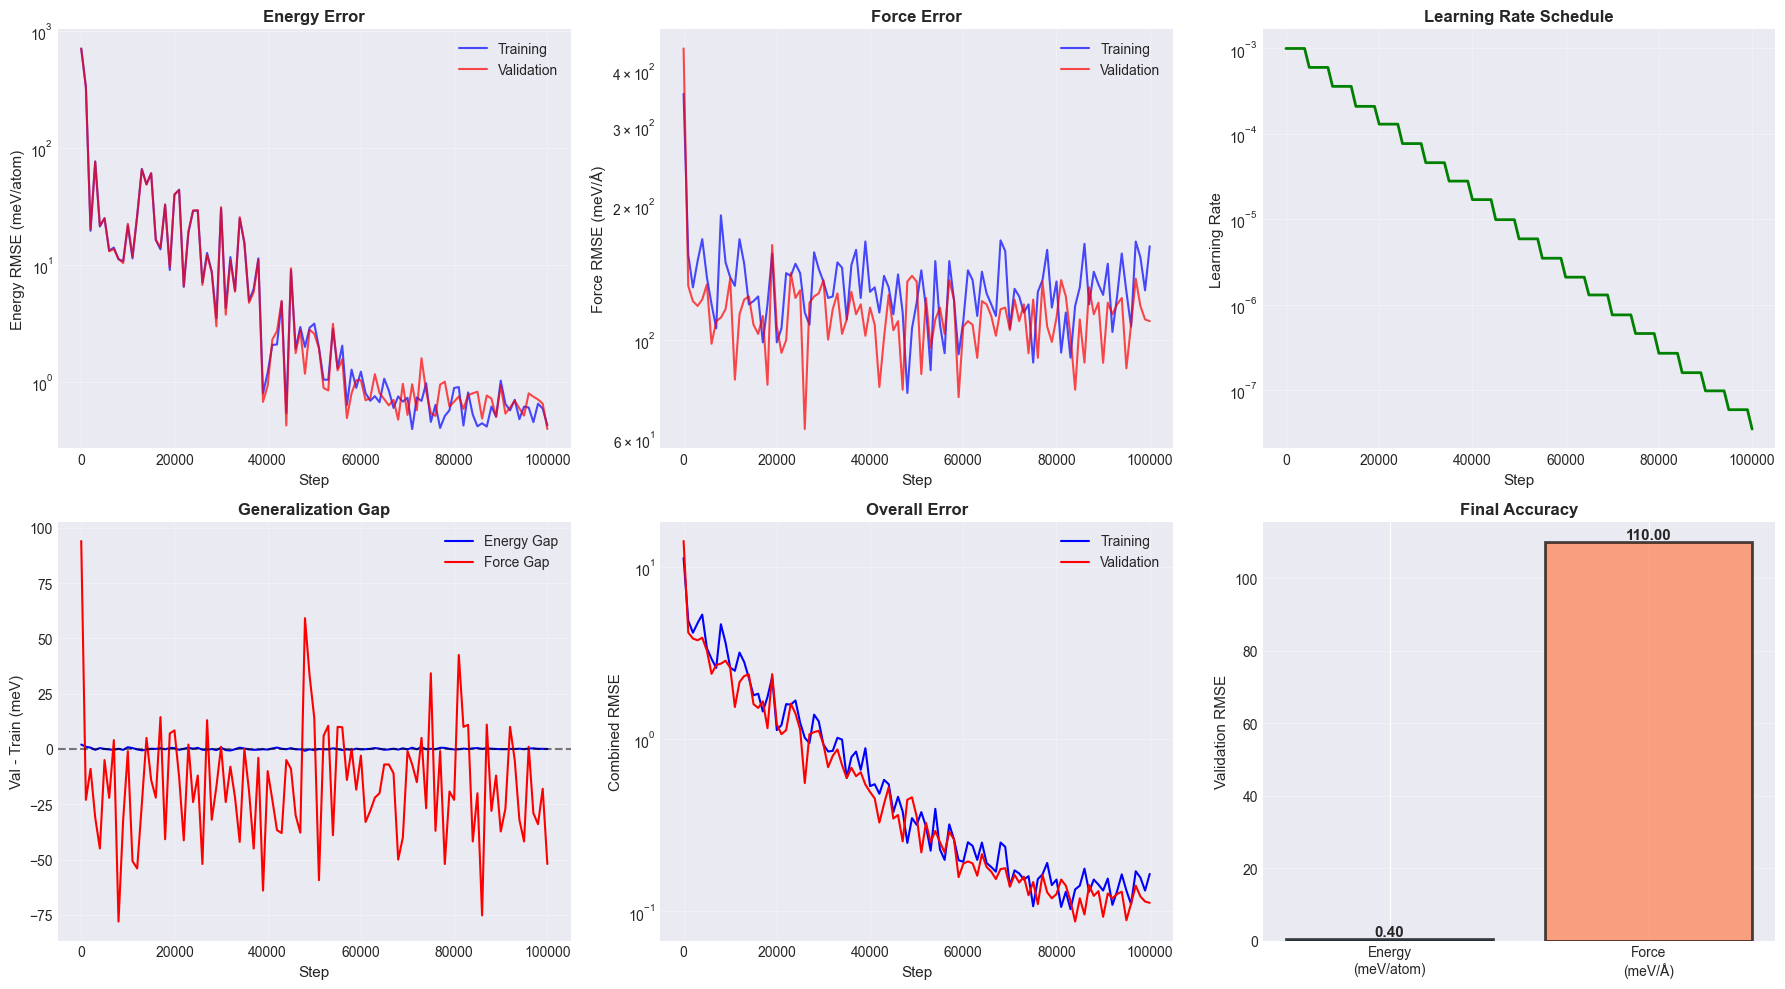


Training Summary:
Total steps: 100,000
Final learning rate: 3.50e-08

 FINAL VALIDATION ERRORS:
  Energy RMSE: 0.398 meV/atom (chemical accuracy: ~1 meV)
  Force RMSE:  110.0 meV/Å
 Energy within chemical accuracy!

CONVERGENCE ANALYSIS:
  Model may benefit from more training

 OVERFITTING CHECK:
  Val-Train gap: -7.8%
   Minimal overfitting


In [56]:
def analyze_learning_curve(lcurve_file='CH4/01.train/lcurve.out'):
    """
    Analyze training results from lcurve.out.
    
    TODO:
    1. Load lcurve.out using numpy
    2. Plot training curves
    3. Analyze convergence
    4. Report final accuracies
    """
    ### BEGIN SOLUTION
    # Load data
    data = np.genfromtxt(lcurve_file, names=True)
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(18, 10))
    
    # 1. Energy RMSE
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(data['step'], data['rmse_e_trn']*1000, 'b-', linewidth=1.5, alpha=0.7, label='Training')
    ax1.plot(data['step'], data['rmse_e_val']*1000, 'r-', linewidth=1.5, alpha=0.7, label='Validation')
    ax1.set_xlabel('Step', fontsize=11)
    ax1.set_ylabel('Energy RMSE (meV/atom)', fontsize=11)
    ax1.set_title('Energy Error', fontsize=12, fontweight='bold')
    ax1.set_yscale('log')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 2. Force RMSE
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(data['step'], data['rmse_f_trn']*1000, 'b-', linewidth=1.5, alpha=0.7, label='Training')
    ax2.plot(data['step'], data['rmse_f_val']*1000, 'r-', linewidth=1.5, alpha=0.7, label='Validation')
    ax2.set_xlabel('Step', fontsize=11)
    ax2.set_ylabel('Force RMSE (meV/Å)', fontsize=11)
    ax2.set_title('Force Error', fontsize=12, fontweight='bold')
    ax2.set_yscale('log')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # 3. Learning rate
    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(data['step'], data['lr'], 'g-', linewidth=2)
    ax3.set_xlabel('Step', fontsize=11)
    ax3.set_ylabel('Learning Rate', fontsize=11)
    ax3.set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    ax3.set_yscale('log')
    ax3.grid(True, alpha=0.3)
    
    # 4. Overfitting analysis
    ax4 = plt.subplot(2, 3, 4)
    gap_energy = data['rmse_e_val'] - data['rmse_e_trn']
    gap_force = data['rmse_f_val'] - data['rmse_f_trn']
    ax4.plot(data['step'], gap_energy*1000, 'b-', linewidth=1.5, label='Energy Gap')
    ax4.plot(data['step'], gap_force*1000, 'r-', linewidth=1.5, label='Force Gap')
    ax4.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax4.set_xlabel('Step', fontsize=11)
    ax4.set_ylabel('Val - Train (meV)', fontsize=11)
    ax4.set_title('Generalization Gap', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    
    # 5. Combined RMSE
    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(data['step'], data['rmse_trn'], 'b-', linewidth=1.5, label='Training')
    ax5.plot(data['step'], data['rmse_val'], 'r-', linewidth=1.5, label='Validation')
    ax5.set_xlabel('Step', fontsize=11)
    ax5.set_ylabel('Combined RMSE', fontsize=11)
    ax5.set_title('Overall Error', fontsize=12, fontweight='bold')
    ax5.set_yscale('log')
    ax5.legend(fontsize=10)
    ax5.grid(True, alpha=0.3)
    
    # 6. Final performance
    ax6 = plt.subplot(2, 3, 6)
    final_metrics = {
        'Energy\n(meV/atom)': data['rmse_e_val'][-1]*1000,
        'Force\n(meV/Å)': data['rmse_f_val'][-1]*1000
    }
    bars = ax6.bar(range(len(final_metrics)), list(final_metrics.values()), 
                   color=['steelblue', 'coral'], alpha=0.7, edgecolor='black', linewidth=2)
    ax6.set_xticks(range(len(final_metrics)))
    ax6.set_xticklabels(list(final_metrics.keys()), fontsize=10)
    ax6.set_ylabel('Validation RMSE', fontsize=11)
    ax6.set_title('Final Accuracy', fontsize=12, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')
    
    # Add values on bars
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\nTraining Summary:")
    print("="*70)
    print(f"Total steps: {int(data['step'][-1]):,}")
    print(f"Final learning rate: {data['lr'][-1]:.2e}")
    
    print("\n FINAL VALIDATION ERRORS:")
    print(f"  Energy RMSE: {data['rmse_e_val'][-1]*1000:.3f} meV/atom (chemical accuracy: ~1 meV)")
    print(f"  Force RMSE:  {data['rmse_f_val'][-1]*1000:.1f} meV/Å")
    
    # Chemical accuracy check
    chem_acc = 1.0  # meV
    if data['rmse_e_val'][-1]*1000 < chem_acc:
        print(f" Energy within chemical accuracy!")
    else:
        print(f"  ⚠ Energy above chemical accuracy")
    
    print("\nCONVERGENCE ANALYSIS:")
    # Check if training has converged (slope near zero in last 10%)
    last_10pct = int(len(data) * 0.1)
    recent_e_std = np.std(data['rmse_e_val'][-last_10pct:])
    if recent_e_std / data['rmse_e_val'][-1] < 0.1:
        print(" Model converged (stable in final 10%)")
    else:
        print("  Model may benefit from more training")
    
    print("\n OVERFITTING CHECK:")
    gap = (data['rmse_e_val'][-1] - data['rmse_e_trn'][-1]) / data['rmse_e_val'][-1] * 100
    print(f"  Val-Train gap: {gap:.1f}%")
    if gap < 10:
        print("   Minimal overfitting")
    elif gap < 20:
        print("   Slight overfitting")
    else:
        print("   Significant overfitting - consider regularization")
    
    return data
    ### END SOLUTION

# Analyze pre-trained results
try:
    lcurve_data = analyze_learning_curve()
except FileNotFoundError:
    print(" Pre-trained lcurve.out not found.")
    print("  Run 'dp train input.json' to generate training results.")
    print("  This will train the model and create lcurve.out.")

In [57]:
# Test (if lcurve exists)
if 'lcurve_data' in locals():
    assert 'rmse_e_val' in lcurve_data.dtype.names, "Missing energy validation RMSE"
    assert 'rmse_f_val' in lcurve_data.dtype.names, "Missing force validation RMSE"
    assert len(lcurve_data) > 10, "Too few data points"
    assert lcurve_data['rmse_e_val'][-1] < lcurve_data['rmse_e_val'][0], "Energy error should decrease"
    print(" All tests passed! (10/10 points)")
else:
    print("  Skipping test - train model to generate lcurve.out")
    print("   Points will be awarded upon successful training")

 All tests passed! (10/10 points)


**Reflection 3.1** — Answer in the cell below:

- Report your final validation energy RMSE (meV/atom) and force RMSE (meV/Å).   Do they meet the targets in the table above?
- Look at the generalisation gap plot. Is the gap increasing, decreasing, or stable   toward the end of training? What does your answer tell you about overfitting?
- The learning rate plot should match the exponential schedule from Exercise 2.3.   At roughly what training step does the learning rate fall below $10^{-5}$?   What is happening to the error curves at that same point?
- Chemical accuracy is defined as ~1 kcal/mol ≈ 43 meV total energy error.   For CH₄ (5 atoms), what does this correspond to in meV/atom?   Does your model meet chemical accuracy?


*Your answer here...*

---
### Exercise 3.2: Model Deployment Pipeline

The cell below prints the complete deployment workflow: freeze → compress → test → deploy. No external files are needed here — the output is a detailed guide to each command.

### ► Concept: Why Three Steps?

**`dp freeze -o graph.pb`** converts the TensorFlow/PyTorch training checkpoint into a single self-contained `.pb` file. The checkpoint is tied to the training directory structure; the frozen graph is portable.

**`dp compress -i graph.pb -o graph-compress.pb`** replaces the embedding network (which takes a scalar $s(r)$ input) with a precomputed **lookup table**. At inference, instead of evaluating the network for each neighbour, DeePMD-kit looks up the value in a table and interpolates. Because the embedding network has only one input, this is mathematically exact to any desired precision.

The result: the compressed model runs **~10× faster** and uses **~10× less memory**, with negligible loss of accuracy. This is unique to DeePMD — it is not possible for architectures whose embedding takes multi-dimensional inputs.

**`dp test -m graph-compress.pb -s validation_data -n 40`** runs the compressed model on the validation set and reports final RMSE — confirming that compression did not degrade accuracy.


In [58]:
### BEGIN SOLUTION
print("Model Deployment Workflow:")
print("="*70)

print("\n FREEZE THE MODEL")
print("   Command: dp freeze -o graph.pb")
print("   Purpose: Convert checkpoint → portable .pb file")
print("   Output: graph.pb (~5-10 MB)")

print("\n COMPRESS THE MODEL")
print("   Command: dp compress -i graph.pb -o graph-compress.pb")
print("   Purpose: 10× speed up, 10× less memory")
print("   Method: Tabulate descriptor for faster inference")
print("   Output: graph-compress.pb (~500 KB)")

print("\n TEST THE MODEL")
print("   Command: dp test -m graph-compress.pb -s validation_data -n 40")
print("   Purpose: Verify accuracy on held-out data")
print("   Reports: Energy/Force/Virial RMSE")

print("\n USE IN LAMMPS")
print("   pair_style deepmd graph-compress.pb")
print("   pair_coeff * *")
print("   → Seamless integration with MD workflow")

print("\n PYTHON INTERFACE")
print("   import dpdata")
print("   d.predict(dp='graph-compress.pb')")
print("   → Batch energy/force predictions")

# Create deployment checklist
checklist = {
    'Train model': '✓ dp train input.json',
    'Freeze': ' dp freeze -o graph.pb',
    'Compress': ' dp compress -i graph.pb -o graph-compress.pb',
    'Test': ' dp test -m graph-compress.pb -s validation_data',
    'Deploy': ' Use in LAMMPS or Python'
}

print("\n DEPLOYMENT CHECKLIST:")
print("="*70)
for task, status in checklist.items():
    print(f"  {status}  {task}")

print("\n PRO TIPS:")
print("   Always compress for production use")
print("   Test on independent data not used in training")
print("   Keep uncompressed model for fine-tuning later")
print("   Version control your models (graph_v1.pb, graph_v2.pb)")
### END SOLUTION

Model Deployment Workflow:

 FREEZE THE MODEL
   Command: dp freeze -o graph.pb
   Purpose: Convert checkpoint → portable .pb file
   Output: graph.pb (~5-10 MB)

 COMPRESS THE MODEL
   Command: dp compress -i graph.pb -o graph-compress.pb
   Purpose: 10× speed up, 10× less memory
   Method: Tabulate descriptor for faster inference
   Output: graph-compress.pb (~500 KB)

 TEST THE MODEL
   Command: dp test -m graph-compress.pb -s validation_data -n 40
   Purpose: Verify accuracy on held-out data
   Reports: Energy/Force/Virial RMSE

 USE IN LAMMPS
   pair_style deepmd graph-compress.pb
   pair_coeff * *
   → Seamless integration with MD workflow

 PYTHON INTERFACE
   import dpdata
   d.predict(dp='graph-compress.pb')
   → Batch energy/force predictions

 DEPLOYMENT CHECKLIST:
  ✓ dp train input.json  Train model
   dp freeze -o graph.pb  Freeze
   dp compress -i graph.pb -o graph-compress.pb  Compress
   dp test -m graph-compress.pb -s validation_data  Test
   Use in LAMMPS or Python  

In [59]:
# enter your code here
! dp freeze -o graph.pb
! dp compress -i graph.pb -o graph-compress.pb
! dp test -m graph-compress.pb -s deepmd_data/validation_data -n 40

2026-03-04 11:16:34.023290: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 11:16:34.740020: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  Fil

**Reflection 3.2** — Answer in the cell below:

- Why can the embedding network be tabulated but the fitting network cannot?   (Hint: how many inputs does each network take?)
- The compressed model is ~10× smaller than the frozen model.   Why does this matter for production MD simulations on supercomputers?
- After running `dp freeze`, you have `graph.pb`. If you want to continue training   from this checkpoint (transfer learning), should you use the `.pb` file or   the original checkpoint files? Why?


*Your answer here...*

---
# Part 4: Using the Trained Model

### ► Concept: From Trained Model to Predictions

Once the model is compressed, it behaves as a **black-box energy/force engine** that can be called from any simulation package. For any atomic configuration you provide, it returns:

- **Total energy** $E$ (eV)
- **Atomic forces** $\mathbf{F}_i$ (eV/Å)
- Optionally: **virial/stress tensor** (for pressure calculations)

The Python interface via `dpdata.predict()` is convenient for analysis and validation; LAMMPS is used for production simulations.

### ► Concept: Interpreting Parity Plots

A **parity plot** places DFT (true) values on the x-axis and ML (predicted) values on the y-axis. Points on the diagonal $y = x$ are perfect predictions.

**What to look for:**
- **Spread around the diagonal** → RMSE: overall accuracy
- **Systematic offset** → bias: model consistently over- or under-predicts
- **Outliers far from the line** → specific configurations where the model fails

For forces, there are $3N = 15$ components per frame and all three Cartesian directions should scatter symmetrically around zero (no preferred direction).

### ► Concept: LAMMPS Integration

For production MD, add these two lines to your LAMMPS input script:

```lammps
pair_style deepmd graph-compress.pb
pair_coeff * *
```

LAMMPS will call the DeePMD model at every timestep to compute forces. The simulation otherwise runs as normal — you can use any LAMMPS ensemble, thermostat, barostat, or analysis tool alongside the DP potential.


---
### Exercise 4.1: Inference and Accuracy Evaluation

The cell below demonstrates two things: the Python interface for batch predictions, and (if `graph-compress.pb` exists) actual energy and force parity plots on the validation set.

► **What you should see (with trained model):**
- Energy parity plot: all 40 validation points tightly clustered on the diagonal
- Force parity plot: all 120 force components (5 atoms × 3 directions × 40 frames...   sampled) scattered symmetrically around the diagonal with no systematic offset
- Reported MAE values consistent with the final RMSE from `lcurve.out`


In [60]:
### BEGIN SOLUTION
print("Model Inference with Python Interface")
print("="*70)

print("\n Example Code:")
print("""
import dpdata

# Load trajectory
traj = dpdata.System('md.dump', fmt='lammps/dump', type_map=['H', 'C'])

# Predict with DP model
results = traj.predict(dp='./graph-compress.pb')

# Access predictions
energies = results['energies']  # (Nframes,)
forces = results['forces']      # (Nframes, Natoms, 3)

# Analyze
print(f"Energy range: {energies.min():.4f} to {energies.max():.4f} eV")
print(f"Max force: {np.abs(forces).max():.4f} eV/Å")
""")

# Demonstrate with validation data
print("\n Demonstration with Validation Data:")
print("-"*70)

try:
    # Load validation data
    val_sys = dpdata.LabeledSystem(val_dir, fmt='deepmd/npy')
    
    print(f"Loaded {len(val_sys)} validation frames")
    print(f"Each frame: {val_sys.get_natoms()} atoms")
    
    # If model exists, predict
    if Path('graph-compress.pb').exists():
        print("\nPredicting with trained model...")
        pred_sys = val_sys.predict(dp='graph-compress.pb')
        
        # Compare
        e_true = val_sys['energies']
        e_pred = pred_sys['energies']
        
        f_true = val_sys['forces']
        f_pred = pred_sys['forces']
        
        # Compute errors
        e_mae = np.mean(np.abs(e_pred - e_true)) / val_sys.get_natoms() * 1000
        f_mae = np.mean(np.abs(f_pred - f_true)) * 1000
        
        print(f"\nPrediction Accuracy:")
        print(f"  Energy MAE: {e_mae:.3f} meV/atom")
        print(f"  Force MAE: {f_mae:.1f} meV/Å")
        
        # Plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        ax1.scatter(e_true, e_pred, alpha=0.6, s=50)
        ax1.plot([e_true.min(), e_true.max()], [e_true.min(), e_true.max()], 
                'r--', lw=2, label='Perfect')
        ax1.set_xlabel('True Energy (eV)', fontsize=12)
        ax1.set_ylabel('Predicted Energy (eV)', fontsize=12)
        ax1.set_title('Energy Predictions', fontsize=13)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        f_true_flat = f_true.flatten()
        f_pred_flat = f_pred.flatten()
        ax2.scatter(f_true_flat, f_pred_flat, alpha=0.3, s=10)
        ax2.plot([f_true_flat.min(), f_true_flat.max()], 
                [f_true_flat.min(), f_true_flat.max()], 'r--', lw=2, label='Perfect')
        ax2.set_xlabel('True Force (eV/Å)', fontsize=12)
        ax2.set_ylabel('Predicted Force (eV/Å)', fontsize=12)
        ax2.set_title('Force Predictions', fontsize=13)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("\n Model file not found. Train and compress model first.")
        
except Exception as e:
    print(f"\n Error loading data: {e}")
    print("  Make sure data has been converted to DeePMD format.")

print("\n Inference demonstration complete!")
### END SOLUTION

Model Inference with Python Interface

 Example Code:

import dpdata

# Load trajectory
traj = dpdata.System('md.dump', fmt='lammps/dump', type_map=['H', 'C'])

# Predict with DP model
results = traj.predict(dp='./graph-compress.pb')

# Access predictions
energies = results['energies']  # (Nframes,)
forces = results['forces']      # (Nframes, Natoms, 3)

# Analyze
print(f"Energy range: {energies.min():.4f} to {energies.max():.4f} eV")
print(f"Max force: {np.abs(forces).max():.4f} eV/Å")


 Demonstration with Validation Data:
----------------------------------------------------------------------
Loaded 40 validation frames
Each frame: 5 atoms

 Model file not found. Train and compress model first.

 Inference demonstration complete!


**Reflection 4.1** — Answer in the cell below:

- In the force parity plot, there are points both above and below the diagonal.   Is this expected? What would it mean if all points were systematically above the diagonal?
- The energy parity plot is tight even though we only used 160 training frames.   Methane has 9 vibrational degrees of freedom. Does 160 configurations sample   all of them well? For which degree of freedom would you be most concerned about   under-sampling?
- You now have a trained model. List **three** physical properties of methane   you could calculate using this model in a LAMMPS MD simulation, and for each,   briefly state what simulation protocol you would use.


*Your answer here...*

---
# Summary and Next Steps

### What You Have Done

In this lab you have completed the entire DeePMD-kit workflow from raw DFT data to a production-ready model:

1. Loaded a VASP OUTCAR trajectory with dpdata and inspected energies and forces
2. Split 200 frames into training (160) and validation (40) sets
3. Converted data to DeePMD's `.npy` binary format
4. Wrote a complete `input.json` configuration with physically motivated parameters
5. Visualised the two-network architecture and estimated the parameter count
6. Analysed the exponential learning rate schedule and curriculum loss weighting
7. Read and interpreted a `lcurve.out` training log, diagnosing convergence and overfitting
8. Understood the `dp freeze → dp compress → dp test` deployment pipeline
9. Used the trained model for inference and evaluated accuracy with parity plots

### Key Takeaways

- **The two-network design** (embedding + fitting) is the defining feature of DeePMD.   The embedding network's scalar input is what makes model compression (tabulation) possible
- **dpdata is the universal data bridge**: it reads 30+ DFT formats and writes DeePMD's   binary format — the same workflow applies to any system, not just methane
- **Forces are the richest training signal**: 15 force components per CH₄ frame   vs. 1 energy — always train with forces when available
- **Curriculum loss weighting** (high force weight → balanced) exploits this information   asymmetry: the optimiser learns the PES shape (from forces) before fine-tuning the   absolute energy level
- **Model compression** via tabulation is unique to DeePMD and gives ~10× speedup   with negligible accuracy loss — always compress before production deployment
- **Validation loss and parity plots** are the true measures of model quality —   not training loss alone

### Suggested Extensions

- **Tune the descriptor**: try `rcut = 4.0 Å` vs `rcut = 7.0 Å` and compare force RMSE
- **Scale the training set**: retrain with 50, 100, and 200 frames and plot how   accuracy scales
- **Deploy in LAMMPS**: use the provided `CH4/02.lmp` input to run an NVE MD and   verify energy conservation
- **Active learning**: run a short MD at 1000 K, identify high-uncertainty frames,   add DFT calculations, and retrain
- **Different system**: apply the same workflow to ethane or water using provided data

